## 1. Import Libraries and Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import time

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
pos_train_df = pd.read_csv('/content/train_Arabic_tweets_positive_20190413.tsv', sep='\t', header=None)
neg_train_df = pd.read_csv('/content/train_Arabic_tweets_negative_20190413.tsv', sep='\t', header=None)
pos_test_df = pd.read_csv('/content/test_Arabic_tweets_positive_20190413.tsv', sep='\t', header=None)
neg_test_df = pd.read_csv('/content/test_Arabic_tweets_negative_20190413.tsv', sep='\t', header=None)

In [ ]:
train_df = pd.concat([pos_train_df, neg_train_df], axis=0).sample(frac=1, random_state=42)
train_df.columns = ['sentiment', 'text']
test_df = pd.concat([pos_test_df, neg_test_df], axis=0).sample(frac=1, random_state=42)
test_df.columns = ['sentiment', 'text']

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

Train shape: (45275, 2)
Test shape: (11520, 2)


## 2. Data Exploration

In [ ]:
train_df.head()

,sentiment,text
21985,pos,مقال يدور حول الحمى يوشك ان يقع فيه 😊
7725,pos,تيشرت القائد 💙
9147,neg,وكل السعوديه بدو ..حتى الحاضره منهم من اصل بدو...
14470,neg,المونافري طلع برهوش .. سدينا 😤
4329,neg,منو خر بيتهم مثلنا 😩


In [ ]:
test_df.head()

,sentiment,text
1078,pos,#مسابقة والجائزة 💰 / من أول من فتق لسانه بالعر...
3563,neg,❥↓🌿🍥 ما لأبن أدم والفخر اوله نطفه وأخره جيفه و...
3299,pos,"✨ لاتحزن ودع القلق,يستجيب لك الكريم هو يأخرها ..."
2142,neg,بيي الله يستر طلعتي من الدوام سيارتي وايد نازل...
5285,neg,تلاتين سنة بترقص .. الليلة رقصتنا أنا ببكي 😭 د...


In [ ]:
print(f"Missing values - Train: {train_df.isna().sum().sum()}, Test: {test_df.isna().sum().sum()}")
print(f"Duplicates - Train: {train_df.duplicated().sum()}, Test: {test_df.duplicated().sum()}")

Missing values - Train: 0, Test: 0
Duplicates - Train: 15721, Test: 2679


In [ ]:
train_df.drop_duplicates(inplace=True)
test_df.drop_duplicates(inplace=True)

print(f"After removing duplicates - Train: {train_df.shape}, Test: {test_df.shape}")

After removing duplicates - Train: (29554, 2), Test: (8841, 2)


In [ ]:
print(f"Train sentiment distribution:")
print(train_df['sentiment'].value_counts(normalize=True) * 100)
print(f"\nTest sentiment distribution:")
print(test_df['sentiment'].value_counts(normalize=True) * 100)

Train sentiment distribution:
sentiment
neg    51.075996
pos    48.924004
Name: proportion, dtype: float64

Test sentiment distribution:
sentiment
neg    50.390227
pos    49.609773
Name: proportion, dtype: float64


## 3. Text Preprocessing

In [ ]:
print(train_df['text'].iloc[0])

مقال يدور حول الحمى يوشك ان يقع فيه 😊


### 3.1 Remove Emojis

In [ ]:
def remove_emojis(text):
    pattern = re.compile("["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
                           "]+", flags=re.UNICODE)
    return pattern.sub(r' ', text)

train_df['text'] = train_df['text'].apply(lambda x: remove_emojis(x))
test_df['text'] = test_df['text'].apply(lambda x: remove_emojis(x))

### 3.2 Remove Punctuation

In [ ]:
punct = string.punctuation
def remove_punct(text):
    return ''.join(x for x in text if x not in punct)

train_df['text'] = train_df['text'].apply(lambda x: remove_punct(x))
test_df['text'] = test_df['text'].apply(lambda x: remove_punct(x))

### 3.3 Remove Stopwords

In [ ]:
def remove_stopwords(text):
    stop_words = set(stopwords.words('arabic'))
    words = text.split()
    return ' '.join([x for x in words if x not in stop_words]).strip()

train_df['text'] = train_df['text'].apply(lambda x: remove_stopwords(x))
test_df['text'] = test_df['text'].apply(lambda x: remove_stopwords(x))

In [ ]:
print(train_df['text'].iloc[0])

مقال يدور حول الحمى يوشك ان يقع


## 4. Encode Target

In [ ]:
mapping = {'neg': 0, 'pos': 1}
train_df['sentiment'] = train_df['sentiment'].map(mapping)
test_df['sentiment'] = test_df['sentiment'].map(mapping)


X_train = train_df['text']
y_train = train_df['sentiment']
X_test = test_df['text']
y_test = test_df['sentiment']

## 5. TF-IDF Vectorization

In [ ]:
vectorizer = TfidfVectorizer(min_df=0.0001, max_df=0.95)
X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

## 6. Model Training and Evaluation

In [ ]:
results = []

def train_and_evaluate(model, model_name, X_train, y_train, X_test, y_test):
    print(f"Training {model_name}...")
    start_time = time.time()

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else y_pred

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    training_time = time.time() - start_time

    print(f"✓ {model_name} completed in {training_time:.2f} seconds")
    print(f"  Accuracy: {accuracy:.4f}, F1-Score: {f1:.4f}\n")

    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'Training Time (s)': training_time
    }

In [ ]:
# 1. Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
results.append(train_and_evaluate(lr_model, 'Logistic Regression', X_train, y_train, X_test, y_test))

Training Logistic Regression...
✓ Logistic Regression completed in 0.78 seconds
  Accuracy: 0.7026, F1-Score: 0.6873



In [ ]:
# 2. Naive Bayes
nb_model = MultinomialNB()
results.append(train_and_evaluate(nb_model, 'Naive Bayes', X_train, y_train, X_test, y_test))

Training Naive Bayes...
✓ Naive Bayes completed in 0.05 seconds
  Accuracy: 0.7103, F1-Score: 0.6924



In [ ]:
# 3. Support Vector Machine
svm_model = SVC(kernel='linear', probability=True, random_state=42)
results.append(train_and_evaluate(svm_model, 'SVM (Linear)', X_train, y_train, X_test, y_test))

Training SVM (Linear)...
✓ SVM (Linear) completed in 484.14 seconds
  Accuracy: 0.7044, F1-Score: 0.6903



In [ ]:
# 4. Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
results.append(train_and_evaluate(dt_model, 'Decision Tree', X_train, y_train, X_test, y_test))

Training Decision Tree...
✓ Decision Tree completed in 30.71 seconds
  Accuracy: 0.7118, F1-Score: 0.6980



In [ ]:
# 5. Random Forest
rf_model = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
results.append(train_and_evaluate(rf_model, 'Random Forest', X_train, y_train, X_test, y_test))

Training Random Forest...
✓ Random Forest completed in 379.71 seconds
  Accuracy: 0.7398, F1-Score: 0.7211



In [ ]:
# 6. Gradient Boosting
gb_model = GradientBoostingClassifier(n_estimators=300, random_state=42)
results.append(train_and_evaluate(gb_model, 'Gradient Boosting', X_train, y_train, X_test, y_test))

Training Gradient Boosting...
✓ Gradient Boosting completed in 31.54 seconds
  Accuracy: 0.6485, F1-Score: 0.5609



In [ ]:
# 7. AdaBoost
ada_model = AdaBoostClassifier(n_estimators=300, random_state=42)
results.append(train_and_evaluate(ada_model, 'AdaBoost', X_train, y_train, X_test, y_test))

Training AdaBoost...
✓ AdaBoost completed in 12.88 seconds
  Accuracy: 0.5882, F1-Score: 0.4113



In [ ]:
# 8. K-Nearest Neighbors
knn_model = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
results.append(train_and_evaluate(knn_model, 'K-Nearest Neighbors', X_train, y_train, X_test, y_test))

Training K-Nearest Neighbors...
✓ K-Nearest Neighbors completed in 19.69 seconds
  Accuracy: 0.6023, F1-Score: 0.5441



In [ ]:
# 9. LightGBM
lgbm_model = LGBMClassifier(n_estimators=300, random_state=42, verbose=-1, n_jobs=-1)
results.append(train_and_evaluate(lgbm_model, 'LightGBM', X_train, y_train, X_test, y_test))

Training LightGBM...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


✓ LightGBM completed in 5.59 seconds
  Accuracy: 0.6660, F1-Score: 0.6308



In [ ]:
# 10. XGBoost
xgb_model = XGBClassifier(n_estimators=300, random_state=42, eval_metric='logloss', n_jobs=-1)
results.append(train_and_evaluate(xgb_model, 'XGBoost', X_train, y_train, X_test, y_test))

Training XGBoost...
✓ XGBoost completed in 24.37 seconds
  Accuracy: 0.6819, F1-Score: 0.6358



## 7. Results Analysis and Comparison

In [ ]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Training Time (s)
0,Random Forest,0.739848,0.770207,0.677839,0.721077,0.818153,379.710443
1,Decision Tree,0.711797,0.726914,0.671227,0.697961,0.723349,30.712044
2,Naive Bayes,0.710327,0.731540,0.657319,0.692446,0.776356,0.052317
3,SVM (Linear),0.704445,0.718835,0.663931,0.690293,0.767346,484.139057
4,Logistic Regression,0.702635,0.718478,0.658687,0.687284,0.767412,0.782102
5,XGBoost,0.681936,0.736053,0.559508,0.635751,0.741678,24.373815
6,LightGBM,0.665988,0.698312,0.575239,0.630829,0.728747,5.594664
7,Gradient Boosting,0.648456,0.737370,0.452576,0.560893,0.705498,31.535387
8,K-Nearest Neighbors,0.602307,0.630788,0.478340,0.544087,0.642378,19.694958
9,AdaBoost,0.588169,0.707059,0.290014,0.411318,0.613733,12.881976


In [ ]:
results_df.to_csv('model_comparison_results.csv', index=False)

In [ ]:
best_model = results_df.iloc[0]
print(f"\n Best Model: {best_model['Model']}")
print(f"   F1-Score: {best_model['F1-Score']:.4f}")
print(f"   Accuracy: {best_model['Accuracy']:.4f}")
print(f"   ROC-AUC: {best_model['ROC-AUC']:.4f}")


 Best Model: Random Forest
   F1-Score: 0.7211
   Accuracy: 0.7398
   ROC-AUC: 0.8182


## 8. Visualization

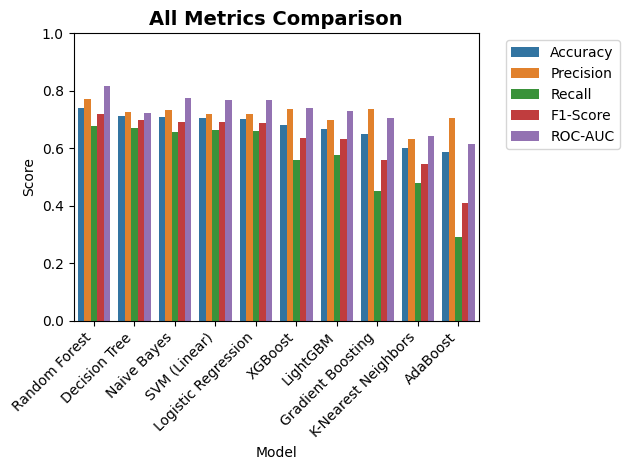

In [ ]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
results_melted = results_df.melt(id_vars='Model', value_vars=metrics_to_plot,
                                  var_name='Metric', value_name='Score')
sns.barplot(data=results_melted, x='Model', y='Score', hue='Metric')
plt.xticks(rotation=45, ha='right')
plt.title('All Metrics Comparison', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1771/3767515014.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y='F1-Score', palette=colors)


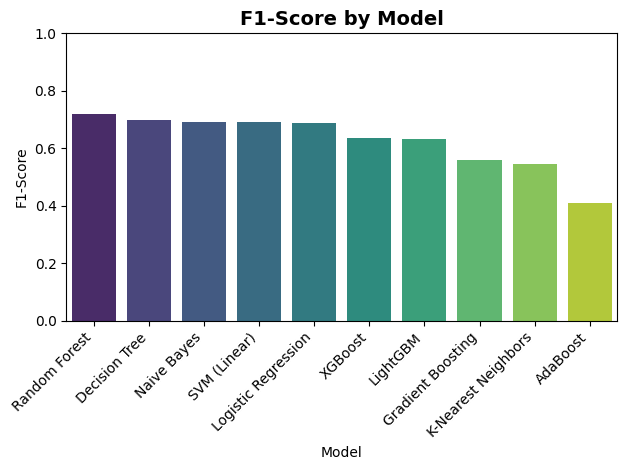

In [ ]:
colors = sns.color_palette('viridis', len(results_df))
sns.barplot(data=results_df, x='Model', y='F1-Score', palette=colors)
plt.xticks(rotation=45, ha='right')
plt.title('F1-Score by Model', fontsize=14, fontweight='bold')
plt.ylabel('F1-Score')
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

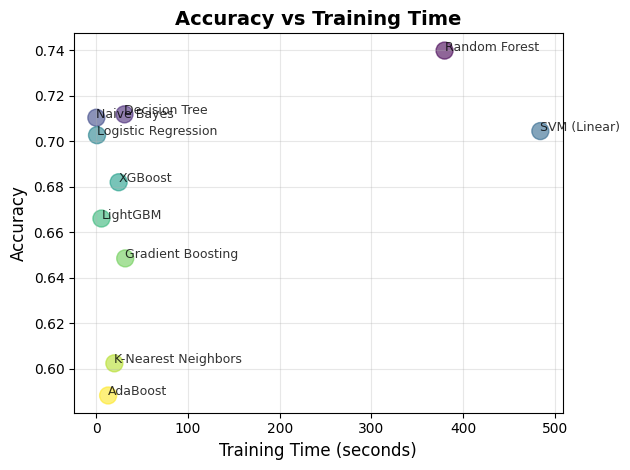

In [ ]:
plt.scatter(results_df['Training Time (s)'], results_df['Accuracy'], s=150, alpha=0.6, c=range(len(results_df)), cmap='viridis')
for i, model in enumerate(results_df['Model']):
    plt.annotate(model, (results_df['Training Time (s)'].iloc[i],
                         results_df['Accuracy'].iloc[i]),
                fontsize=9, alpha=0.8)
plt.xlabel('Training Time (seconds)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Accuracy vs Training Time', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1771/2747913068.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y='ROC-AUC', palette=colors)


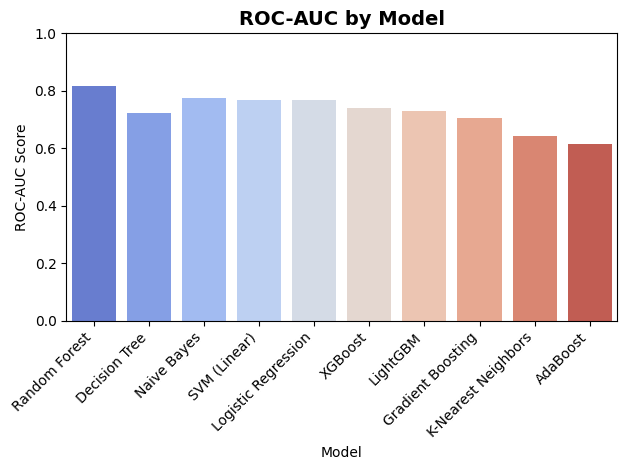

In [ ]:
colors = sns.color_palette('coolwarm', len(results_df))
sns.barplot(data=results_df, x='Model', y='ROC-AUC', palette=colors)
plt.xticks(rotation=45, ha='right')
plt.title('ROC-AUC by Model', fontsize=14, fontweight='bold')
plt.ylabel('ROC-AUC Score')
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

## Simple RNN Model with Embeddings


## 9. RNN Models with Embeddings

> In this section we re-use the **raw text** (after preprocessing) and train three RNN-based architectures:
> **Simple RNN**, **LSTM**, and **Bi-LSTM**.
> We tokenise the corpus, pad sequences, and learn a dense word-embedding jointly with each model.

In [ ]:
#   Extra imports
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, SimpleRNN, LSTM,
                                     Bidirectional, Dense, Dropout,
                                     SpatialDropout1D)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import plot_model
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


### 9.2 Prepare Text & Labels for Deep Learning

The TF-IDF step destroyed the raw strings, so we reconstruct the splits from the original (pre-vectorised) DataFrames.

In [ ]:
# Re-read the cleaned text from the DataFrames used before TF-IDF
# train_df / test_df still hold the preprocessed text column
X_train_text = train_df['text'].astype(str).values
X_test_text  = test_df['text'].astype(str).values
y_train_dl   = train_df['sentiment'].values
y_test_dl    = test_df['sentiment'].values

print(f"Train samples : {len(X_train_text)}")
print(f"Test  samples : {len(X_test_text)}")
print(f"Sample tweet  : {X_train_text[0]}")


Train samples : 29554
Test  samples : 8841
Sample tweet  : مقال يدور حول الحمى يوشك ان يقع


## RNN Implementation

In [ ]:
import numpy as np
import pandas as pd
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, LSTM, Bidirectional, Dense, Dropout, SimpleRNN,
    GlobalMaxPooling1D, LayerNormalization, Input
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
import zipfile
import os
import urllib.request

In [ ]:
#  Hyperparameters
VOCAB_SIZE = 30_000
MAX_LEN = None
EMBED_DIM = 300
OOV_TOKEN = '<OOV>'
BATCH_SIZE = 64
EPOCHS = 30

In [ ]:
# Text Cleaning Function
def clean_text(text):
    text = text.lower()
    text = re.sub(f'[{re.escape(string.punctuation)}]', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [ ]:
# Apply cleaning
X_train_text = [clean_text(txt) for txt in X_train_text]
X_test_text  = [clean_text(txt) for txt in X_test_text]

In [ ]:

#  Adaptive Sequence Length

temp_tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
temp_tokenizer.fit_on_texts(X_train_text)
temp_seqs = temp_tokenizer.texts_to_sequences(X_train_text)
lengths = [len(seq) for seq in temp_seqs]
MAX_LEN = int(np.percentile(lengths, 95))
print(f"Auto MAX_LEN = {MAX_LEN}")


Auto MAX_LEN = 18


In [ ]:

# Final Tokenizer & Padding

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train_text)

train_seq = tokenizer.texts_to_sequences(X_train_text)
test_seq  = tokenizer.texts_to_sequences(X_test_text)

X_train_pad = pad_sequences(train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')
print(f"X_train_pad shape: {X_train_pad.shape}")
print(f"X_test_pad shape: {X_test_pad.shape}")


X_train_pad shape: (29554, 18)
X_test_pad shape: (8841, 18)


In [ ]:

#  Load GloVe Embeddings
glove_url = "http://nlp.stanford.edu/data/glove.6B.zip"
glove_zip = "glove.6B.zip"
if not os.path.exists(glove_zip):
    urllib.request.urlretrieve(glove_url, glove_zip)
    with zipfile.ZipFile(glove_zip, 'r') as zip_ref:
        zip_ref.extractall("glove")

embedding_index = {}
with open(f"glove/glove.6B.{EMBED_DIM}d.txt", encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = coefs

word_index = tokenizer.word_index
embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM))
for word, i in word_index.items():
    if i < VOCAB_SIZE:
        emb_vec = embedding_index.get(word)
        if emb_vec is not None:
            embedding_matrix[i] = emb_vec

In [ ]:
def build_rnn(vocab_size, max_len, embed_dim, embedding_matrix):
    model = Sequential(name="RNN_Model")
    model.add(Embedding(vocab_size, embed_dim,
                        weights=[embedding_matrix],
                        trainable=True,
                        input_length=max_len,
                        mask_zero=False))
    model.add(SimpleRNN(128, return_sequences=False, dropout=0.3, recurrent_dropout=0.3,
                        kernel_regularizer=l2(1e-5)))
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(1e-4)))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))

    # FORCE BUILD - this eliminates all ? and unbuilt layers
    model.build(input_shape=(None, max_len))
    return model

def build_lstm(vocab_size, max_len, embed_dim, embedding_matrix):
    model = Sequential(name="LSTM_Model")
    model.add(Embedding(vocab_size, embed_dim,
                        weights=[embedding_matrix],
                        trainable=True,
                        input_length=max_len))
    model.add(LSTM(128, return_sequences=False, dropout=0.3, recurrent_dropout=0.3,
                   kernel_regularizer=l2(1e-5)))
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(1e-4)))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))

    # FORCE BUILD
    model.build(input_shape=(None, max_len))
    return model

def build_bilstm(vocab_size, max_len, embed_dim, embedding_matrix):
    model = Sequential(name="BiLSTM_Model")
    model.add(Embedding(vocab_size, embed_dim,
                        weights=[embedding_matrix],
                        trainable=True,
                        input_length=max_len))
    model.add(Bidirectional(LSTM(128, return_sequences=False, dropout=0.3,
                                 recurrent_dropout=0.3, kernel_regularizer=l2(1e-5))))
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(1e-4)))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))

    # FORCE BUILD
    model.build(input_shape=(None, max_len))
    return model

In [ ]:

#  Training Function
def train_and_evaluate(model_builder, model_name):
    print(f"\n{'='*50}\nTraining {model_name}\n{'='*50}")
    model = model_builder(VOCAB_SIZE, MAX_LEN, EMBED_DIM, embedding_matrix)
    optimizer = Adam(learning_rate=1e-3, clipnorm=1.0)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    model.summary()

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
        ModelCheckpoint(f'best_{model_name}.h5', monitor='val_accuracy',
                        save_best_only=True, mode='max', verbose=1)
    ]

    history = model.fit(
        X_train_pad, y_train,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        validation_split=0.1,
        callbacks=callbacks,
        verbose=1
    )

    # Load best weights
    model.load_weights(f'best_{model_name}.h5')
    test_loss, test_acc = model.evaluate(X_test_pad, y_test, verbose=0)
    print(f"\n{model_name} Test Accuracy: {test_acc:.4f}")

    y_pred_prob = model.predict(X_test_pad)
    y_pred = (y_pred_prob > 0.5).astype(int)
    print(f"\n{model_name} Classification Report:")
    print(classification_report(y_test, y_pred))
    print(f"\n{model_name} Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    return history, test_acc

In [ ]:
#  Train RNN model

history_rnn, acc_rnn = train_and_evaluate(build_rnn, "RNN")



Training RNN


Model: "RNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ (None, 18, 300)        │     9,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 128)            │        54,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,063,233 (34.57 MB)

 Trainable params: 9,063,233 (34.57 MB)

...


Epoch 3: finished saving model to best_RNN.h5
416/416 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5876 - loss: 0.6785 - val_accuracy: 0.6028 - val_loss: 0.6765 - learning_rate: 0.0010
Epoch 4/30
407/416 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6482 - loss: 0.6499
Epoch 4: val_accuracy improved from 0.60284 to 0.62652, saving model to best_RNN.h5



Epoch 4: finished saving model to best_RNN.h5
416/416 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6466 - loss: 0.6527 - val_accuracy: 0.6265 - val_loss: 0.6626 - learning_rate: 0.0010
Epoch 5/30
415/416 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6796 - loss: 0.6247
Epoch 5: val_accuracy improved from 0.62652 to 0.66915, saving model to best_RNN.h5



Epoch 5: finished saving model to best_RNN.h5
416/416 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6908 - loss: 0.6170 - val_accuracy: 0.6691 - val_loss: 0.6683 - learning_rate: 0.0010
Epoch 6/30
415/416 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7348 - loss: 0.5681
Epoch 6: val_accuracy did not improve from 0.66915
416/416 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7366 - loss: 0.5672 - val_accuracy: 0.6685 - val_loss: 0.7075 - learning_rate: 0.0010
Epoch 7/30
416/416 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7798 - loss: 0.5131
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 7: val_accuracy improved from 0.66915 to 0.67760, saving model to best_RNN.h5



Epoch 7: finished saving model to best_RNN.h5
416/416 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7754 - loss: 0.5184 - val_accuracy: 0.6776 - val_loss: 0.7483 - learning_rate: 0.0010
Epoch 8/30
411/416 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8175 - loss: 0.4591
Epoch 8: val_accuracy improved from 0.67760 to 0.68302, saving model to best_RNN.h5



Epoch 8: finished saving model to best_RNN.h5
416/416 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8156 - loss: 0.4626 - val_accuracy: 0.6830 - val_loss: 0.7515 - learning_rate: 5.0000e-04
Epoch 9/30
407/416 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8400 - loss: 0.4306
Epoch 9: val_accuracy did not improve from 0.68302
416/416 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8386 - loss: 0.4312 - val_accuracy: 0.6796 - val_loss: 0.7654 - learning_rate: 5.0000e-04
Epoch 9: early stopping
Restoring model weights from the end of the best epoch: 4.

RNN Test Accuracy: 0.7305
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

RNN Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.80      0.75      4455
           1       0.76      0.66      0.71      4386

    accuracy                           0.73      8841
   macro avg       0.73      0.73      0.73      8841
weighted avg       0.73      0.73      0.73      8841


RNN Confusion Matri

In [ ]:
#  Train LSTM model

history_lstm, acc_lstm = train_and_evaluate(build_lstm, "LSTM")



Training LSTM


Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ (None, 18, 300)        │     9,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 128)            │       219,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,227,969 (35.20 MB)

 Trainable params: 9,227,969 (35.20 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
416/416 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.6025 - loss: 0.6656
Epoch 1: val_accuracy improved from None to 0.69926, saving model to best_LSTM.h5



Epoch 1: finished saving model to best_LSTM.h5
416/416 ━━━━━━━━━━━━━━━━━━━━ 40s 87ms/step - accuracy: 0.6493 - loss: 0.6337 - val_accuracy: 0.6993 - val_loss: 0.5712 - learning_rate: 0.0010
Epoch 2/30
416/416 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.7937 - loss: 0.4677
Epoch 2: val_accuracy did not improve from 0.69926
416/416 ━━━━━━━━━━━━━━━━━━━━ 39s 83ms/step - accuracy: 0.7830 - loss: 0.4777 - val_accuracy: 0.6864 - val_loss: 0.5795 - learning_rate: 0.0010
Epoch 3/30
416/416 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.8638 - loss: 0.3380
Epoch 3: val_accuracy did not improve from 0.69926
416/416 ━━━━━━━━━━━━━━━━━━━━ 35s 84ms/step - accuracy: 0.8488 - loss: 0.3569 - val_accuracy: 0.6861 - val_loss: 0.7089 - learning_rate: 0.0010
Epoch 4/30
416/416 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.8939 - loss: 0.2542
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 4: val_accuracy did not improve from 0.69926
416/416 ━━━━━━━━━━━━━━━━━━━━ 37s

In [ ]:
#  Train BiLSTM model

history_bilstm, acc_bilstm = train_and_evaluate(build_bilstm, "BiLSTM")


Training BiLSTM


Model: "BiLSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)        │ (None, 18, 300)        │     9,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_8 (Bidirectional) │ (None, 256)            │       439,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,455,809 (36.07 MB)

 Trainable params: 9,455,809 (36.07 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
416/416 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.6111 - loss: 0.6617
Epoch 1: val_accuracy improved from None to 0.70230, saving model to best_BiLSTM.h5



Epoch 1: finished saving model to best_BiLSTM.h5
416/416 ━━━━━━━━━━━━━━━━━━━━ 70s 146ms/step - accuracy: 0.6543 - loss: 0.6254 - val_accuracy: 0.7023 - val_loss: 0.5653 - learning_rate: 0.0010
Epoch 2/30
416/416 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.8066 - loss: 0.4383
Epoch 2: val_accuracy did not improve from 0.70230
416/416 ━━━━━━━━━━━━━━━━━━━━ 80s 142ms/step - accuracy: 0.7957 - loss: 0.4503 - val_accuracy: 0.6932 - val_loss: 0.6007 - learning_rate: 0.0010
Epoch 3/30
416/416 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.8792 - loss: 0.2961
Epoch 3: val_accuracy did not improve from 0.70230
416/416 ━━━━━━━━━━━━━━━━━━━━ 58s 138ms/step - accuracy: 0.8696 - loss: 0.3127 - val_accuracy: 0.6881 - val_loss: 0.7271 - learning_rate: 0.0010
Epoch 4/30
416/416 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.9250 - loss: 0.1917
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 4: val_accuracy did not improve from 0.70230
416/416 ━━━━━━━━━━━━━━━━

In [ ]:
# Predictions
y_pred_prob = model.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int)

277/277 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step


In [ ]:

#  Compare Results
print("\n" + "="*50)
print("FINAL ACCURACY COMPARISON")
print("="*50)
print(f"RNN      : {acc_rnn:.4f}")
print(f"LSTM     : {acc_lstm:.4f}")
print(f"BiLSTM   : {acc_bilstm:.4f}")


FINAL ACCURACY COMPARISON
RNN      : 0.7305
LSTM     : 0.7411
BiLSTM   : 0.7408


In [ ]:
print("\nClassification Report:")
print(classification_report(y_test_dl, y_pred)) # Use y_test_dl


Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.80      0.76      4455
           1       0.77      0.69      0.73      4386

    accuracy                           0.75      8841
   macro avg       0.75      0.75      0.75      8841
weighted avg       0.75      0.75      0.75      8841



In [ ]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_dl, y_pred)) # Use y_test_dl


Confusion Matrix:
[[3562  893]
 [1341 3045]]


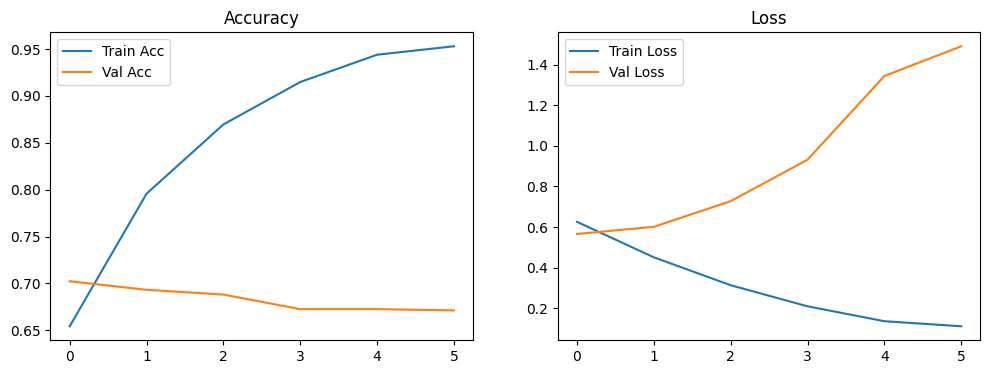

In [ ]:
# Optional: plot learning curves
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history_bilstm.history['accuracy'], label='Train Acc')
plt.plot(history_bilstm.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history_bilstm.history['loss'], label='Train Loss')
plt.plot(history_bilstm.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

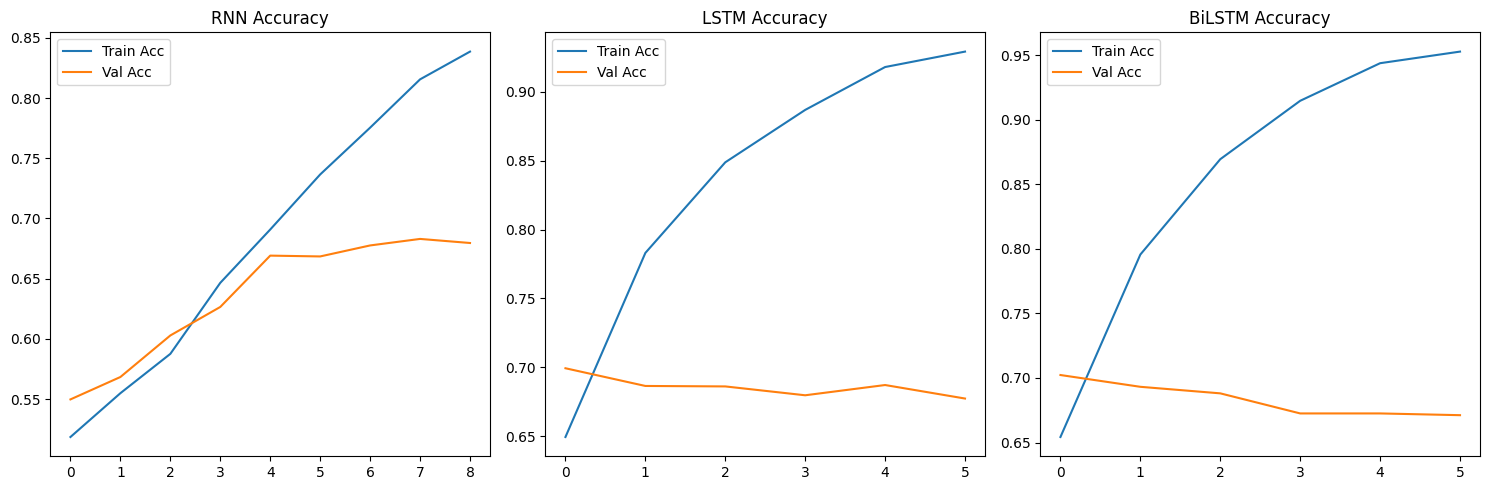

In [ ]:
#  Plot training curves
import matplotlib.pyplot as plt
plt.figure(figsize=(15,5))
for i, (hist, name) in enumerate([(history_rnn, 'RNN'), (history_lstm, 'LSTM'), (history_bilstm, 'BiLSTM')]):
    plt.subplot(1,3,i+1)
    plt.plot(hist.history['accuracy'], label='Train Acc')
    plt.plot(hist.history['val_accuracy'], label='Val Acc')
    plt.title(f'{name} Accuracy')
    plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# test_model.py
import pickle
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

# Define clean_text function (as it was defined in cell 9ywvcMus7Gyp)
def clean_text(text):
    text = text.lower()
    text = re.sub(f'[{re.escape(string.punctuation)}]', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Define preprocess_new_texts function (mimics tokenizer and padding logic)
def preprocess_new_texts(texts, tokenizer, max_len):
    cleaned_texts = [clean_text(txt) for txt in texts]
    sequences = tokenizer.texts_to_sequences(cleaned_texts)
    padded_sequences = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')
    return padded_sequences

# Ensure tokenizer.pkl and max_len.pkl exist by creating them if necessary
import os
import string

if not os.path.exists('tokenizer.pkl') or not os.path.exists('max_len.pkl'):
    print("Tokenizer or MAX_LEN not found, recreating and saving...")

    # These variables are assumed to be available from earlier notebook execution
    global VOCAB_SIZE, OOV_TOKEN, X_train_text, MAX_LEN, tokenizer

    # Adaptive Sequence Length (from 9X66o7Ef7MxS)
    temp_tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
    temp_tokenizer.fit_on_texts(X_train_text)
    temp_seqs = temp_tokenizer.texts_to_sequences(X_train_text)
    lengths = [len(seq) for seq in temp_seqs]
    MAX_LEN = int(np.percentile(lengths, 95))
    print(f"Re-calculated MAX_LEN = {MAX_LEN}")

    # Final Tokenizer & Padding (from m-fZn51x7QcB)
    tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
    tokenizer.fit_on_texts(X_train_text)

    # Save the tokenizer and MAX_LEN
    with open('tokenizer.pkl', 'wb') as f:
        pickle.dump(tokenizer, f)
    with open('max_len.pkl', 'wb') as f:
        pickle.dump(MAX_LEN, f)
    print("Tokenizer and MAX_LEN saved.")

# Load saved objects (now they should exist)
with open('tokenizer.pkl', 'rb') as f:
    tokenizer = pickle.load(f)
with open('max_len.pkl', 'rb') as f:
    MAX_LEN = pickle.load(f)

model = load_model('best_LSTM.h5')

new_texts = ["I love this!", "Horrible."]
X = preprocess_new_texts(new_texts, tokenizer, MAX_LEN)
preds = model.predict(X)
for txt, p in zip(new_texts, preds):
    print(f"{txt} -> {p[0]:.4f} ({'POS' if p[0]>0.5 else 'NEG'})")

Tokenizer or MAX_LEN not found, recreating and saving...
Re-calculated MAX_LEN = 18
Tokenizer and MAX_LEN saved.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step
I love this! -> 0.8348 (POS)
Horrible. -> 0.3648 (NEG)
